In [19]:
#  Copyright 2020 Forschungszentrum Jülich GmbH and Aix-Marseille Université
# "Licensed to the Apache Software Foundation (ASF) under one or more contributor license agreements; and to You under the Apache License, Version 2.0. "
# import os

import numpy.random as rgn
import numpy as np
# from nest_elephant_tvb.Tvb.wrapper_TVB import simulate_tvb
# from nest_elephant_tvb.Tvb.helper_function import CorticalSurface_new, LocalConnectivity_new, LaplaceKernel, Heaviside

#  Copyright 2020 Forschungszentrum Jülich GmbH and Aix-Marseille Université
# "Licensed to the Apache Software Foundation (ASF) under one or more contributor license agreements; and to You under the Apache License, Version 2.0. "
from pathlib  import Path
# import tvb.simulator.lab as lab
from tvb.simulator.lab import *
from scipy.sparse import data, save_npz, load_npz
import h5py# as h5
import logging
import time
logging.getLogger('numba').setLevel(logging.WARNING)
logging.getLogger('tvb').setLevel(logging.ERROR)

from nibabel.freesurfer.io import read_geometry, read_annot, read_morph_data

#from utils_py.utils import *
from utils_py.utils import delete_vertices_from_triangular_mesh, Heaviside_Sparse, Connectivity_Sparse, CorticalSurface_new, \
                            LocalConnectivity_new, LaplaceKernel, Simulator_Sparse

start_time=time.time()

## initialise the random generator
rgn.seed(455)






### Region selection

In [20]:
#-----------------
# Data directories
#-----------------
data_dir = Path('../Data/high_density_brain/')
T1w_dir = data_dir/'T1w'                        # Diffusion weighted data
sub = "100206"                                  # labels et al
utils_dir = Path('./utils_py')                  # Utils
#utils_dir   = "../../example/utils_py"

# a mapping of nodes to regions (eg nodes 0 to 238 correspond to region 9, ..., last node corresponds to region 93)
region_map = np.genfromtxt(T1w_dir/"Diffusion"/"vert2vert_region_mapping_resliced.txt")  
# names of regions (eg region 0 is called 'ctx-lh-bankssts', ..., region 9 is 'ctx-lh-lateraloccipital', ...)
region_names = list(np.genfromtxt(utils_dir/"fs_default_HC.txt", usecols=1, dtype=str))
#----------------------
#print('region names: ',region_names)
#----------------------

# select subset of regions
select_regions = ['ctx-rh-fusiform','ctx-rh-parahippocampal','ctx-rh-entorhinal','ctx-rh-Subiculum', 
        'ctx-rh-CA1', 'ctx-rh-CA2', 'ctx-rh-CA3', 'ctx-rh-CA4', 'ctx-rh-Dentate-gyrus']
# Give some verbose
n_regions=len(select_regions)
print(f'selected {n_regions} regions')

# A mask we will create to select the regions, considering many nodes can represent the same regions
# mask = np.ones(region_map.shape[0], dtype=bool)
mask = np.zeros(region_map.shape[0], dtype=bool)  # Initialize a mask for the region_map ndarray
for n in select_regions:                # For each selected region
        n_i = region_names.index(n)     # translate region name to region number
        mask[region_map == n_i] = True  # and add the nodes corresponding to that region to the mask
selected_nodes = region_map[mask]                 # Apply the mask

# CA1 nodes ids, used to mask global and local connectivity
# coupling_region=np.argwhere(selected_nodes==region_names.index('ctx-rh-CA1'))[:,0]     

selected 9 regions


### Mesh vertices and triangles

In [21]:
# Read triangular surface mesh (from a Freesurfer file); 
# # returns vertices(=voxels) coordinates, triangles (defined as triads of nodes) and volume info
lh_v,lh_t, vol_info = read_geometry(T1w_dir/sub/'surf'/'lh.hc_dg_cort_mid', read_metadata=True)
rh_v,rh_t, vol_info = read_geometry(T1w_dir/sub/'surf'/'rh.hc_dg_cort_mid', read_metadata=True)
# Shift the voxels according by cras (not sure what cras is though)
# # RAS (Right, Anterior, Superior) is a coordinate system, but that's a redefinition of the axes, not a reference point.
# # an hypothesis is that xras, yras, zras and cras are values necessary to transform to RAS coordinates. 
# # cras would be a shift (in mm?) and xyz/ras are reflections. 
# # So to actually transform to ras coordinates, we'd need to do (I checked it works): 
# # lh_v = lh_v*vol_info['xras'] + lh_v*vol_info['yras'] + lh_v*vol_info['zras'] + vol_info['cras']
lh_v += vol_info['cras']
rh_v += vol_info['cras']
# Merge left and right
v = np.concatenate((lh_v,rh_v))                 # nodes coordinates
t = np.concatenate((lh_t, rh_t+lh_v.shape[0]))  # nodes defining each triangle; right nodes are shifted to not overlap left nodes
n_vert = v.shape[0]                             # total number of vertices


# Delete not selected nodes
vert,tri,[] = delete_vertices_from_triangular_mesh(v,t,np.invert(mask[:n_vert]),[], remove_new_isolated_vertices=False)
print('simulating vertices with shape',vert.shape,flush=True)
n_vert = vert.shape[0]                          # updated total number of vertices

simulating vertices with shape (16636, 3)


### Coupling, Integrator and Monitors

In [23]:
dt=0.1               # time step
nsigma = 0.035*2     # noise amplitude 
nsig = np.array([    # noise amplitude array
    nsigma,   # x1
    0.0,      # y1
    0.0,      # z
    nsigma,   # x2
    0.0,      # y2
    0.0       # g
])

#----------
# Coupling
#----------
# Coulpling: A function rescaling the connectivity according to pre- and/or post-synaptic processing, and/or a rescaling of the connectivity
# # it is evaluated after passing throught the long-range connectivity and before the local dynamics. 

# Heaviside_Sparse is defined in utils. It's derived from SparseCoupling and implements a rescaled heaviside function.
# # "a" rescales postsynaptically and theta filters runs a heaviside function (0 if x<theta, 0.5 if x=theta, 1 if x>theta). 
# coupl = Heaviside_Sparse(a=np.array([0.01]), b=np.array([0]))
coupl = Heaviside_Sparse(a=np.array([0.01]), theta=np.array([-1])) 

#------------
# Integrator 
#------------
# Heun Deterministic integrator
heunint = integrators.HeunDeterministic(dt=dt)   

# heunint=integrators.HeunStochastic(
#         dt=dt,
#         noise=noise.Additive(
#             nsig=nsig,
#             # nsig=np.array([nsigma]),
#             # nsig=np.array(
#                 # [nsigma,nsigma*2]
#             # ), 
#             noise_seed=42)
#     )

#----------
# Monitors
#----------
#monitor_TAVG = monitors.TemporalAverage(period=.5)     # Temporal average monitor
# monitor_TAVG = monitors.TemporalAverage(period=0.1)
monitor_Raw = monitors.Raw()                           # RAW monitor
#mons = [monitor_TAVG, monitor_Raw]                     # put together in a list
mons = [monitor_Raw]                     # put together in a list

print('monitors in use:')
print(mons)

monitors in use:


### Global Connectivity

In [5]:
# Weights and lengths for global connectivity
v2v_weights = load_npz(T1w_dir/"Diffusion"/"vert2vert_weights_15M.npz")  # Weights
v2v_lengths = load_npz(T1w_dir/"Diffusion"/"vert2vert_lengths_15M.npz")  # Lengths

# mask selected regions
v2v_lengths = v2v_lengths[mask,:][:,mask]      # Lengths
v2v_weights = v2v_weights[mask,:][:,mask]      # Weights
# v2v_weights = v2v_weights/v2v_weights.max()  # Normalize (or don't)
# v2v_weights.data=np.zeros_like(v2v_weights.data)

print(f"connectivity with : {v2v_weights.nnz} non null values")

#--------------
# Connectivity
#--------------
# Connectivity_Sparse is derived from connectivity.Connectivity, adapted to use npz data
con = Connectivity_Sparse(weights=v2v_weights,                                                 # weights 
                                tract_lengths=v2v_lengths,                                     # lengths
                                speed=np.array([3.6]),                                         # Propagation speed (in m/s?)
                                #region_labels=np.array([str(i) for i in range(n_regions)]),   # labels for regions
                                centres = np.zeros((n_regions,3)),                             # the center of center each region is (0,0,0)
                                cortical=np.ones((n_regions),dtype=bool))                      # consider all as cortical (?)
    
con.configure()
con.set_idelays(heunint.dt)   # Convert time delays (from ms?) to time step units. 

connectivity with : 230631 non null values


### Local Connectivity + Surface

In [6]:
#------------------
# Cortical surface 
#------------------
# CorticalSurface_new is derived from surfaces.CorticalSurface to "add functionality to compute vertex area to surface"
# # A cortical surface simply includes vertices and triangles (I guess)
cort_surf = CorticalSurface_new(vertices=vert, triangles=tri)  # Include vertices and triangles to the cortical surface
cort_surf.configure()                                          

#----------------
# Region mapping
#----------------
node_labels = np.arange(con.number_of_regions,dtype='i')                  # Dummy list with labels for each region
# region_mapping is a module from tvb.datatypes.region_mapping.py (imported through tvb.simulator)
region_map = region_mapping.RegionMapping(array_data = node_labels,       # It requires the labels for each region,
                                        connectivity = con,               # the global connectivity, 
                                        surface = cort_surf)              # and the cortical surface structure

#--------------------
# Local connectivity
#--------------------
# We'll need the vertex volumes
vertex_volumes = np.concatenate((read_morph_data(T1w_dir/sub/'surf'/"lh.hc_dg_cort.vertex_volume"),
                                read_morph_data(T1w_dir/sub/'surf'/"rh.hc_dg_cort.vertex_volume"),
                                np.load(T1w_dir/sub/'mri'/"aseg_subcort_numbered_vox.vertex_volume.npz")['vertex_volume']
                                ))
vertex_volumes = vertex_volumes[mask]      # Filter for selected regions



# We'll also need the geodesical distance between nodes (vertices). 
# # Notice this is different from the eucledian distance, as the geodesic distance requires a geometrical model for the head. In our case, 
# # we have directly the geodesic distance, but if we didn't I guess we'd need to estimate it by using the head geometry model
v2v_gdist   = load_npz(T1w_dir/"Diffusion"/"vert2vert_gdist_mat.npz")
v2v_gdist   = v2v_gdist[mask,:][:,mask]

# We'll combine those elements, together with a propagation kernel, to build the local connectivity model
# LocalConnectivity_new is derived from local_connectivity.LocalConnectivity. It includes, as optional parameter, 
# # the vertex areas. In any case, it calls scipy.sparse.diags (I don't know what it does though)
loc_conn = LocalConnectivity_new(equation=LaplaceKernel(), cutoff=10.0) # We'll use a Laplace kernel (not sure why, and it is user-defined),
loc_conn.matrix_gdist = v2v_gdist                                       # geodesic distances,
loc_conn.equation.parameters['b'] = 1                                   # parameters for the Kernel
loc_conn.equation.parameters['amp'] = 1
loc_conn.surface = cort_surf                                            # the cortical surface
loc_conn.compute(vertex_volumes)                                        # and vertex volumes #add subcortical regions to local connectivity
# loc_conn.compute()


#--------
# Cortex
#--------
# construct the Cortex object for TVB
surf = cortex.Cortex(local_connectivity=loc_conn,         # Including local connectivity,
                    region_mapping_data=region_map,       # region mapping
                    coupling_strength=np.array([0.001]))  # and a coupling strength
                    # coupling_strength=np.array([1]))
surf.configure() 

/home/joshua/miniconda3/envs/tvb/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/joshua/miniconda3/envs/tvb/lib/python3.13/site-packages/numpy/_core/_methods.py:137: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


In [7]:
print("Mask shape:", mask.shape)
print("vertex_volumes shape (after masking):", vertex_volumes.shape)
print("Any NaNs?", np.isnan(vertex_volumes).any())
print("v2v_gdist shape:", v2v_gdist.shape)

Mask shape: (435490,)
vertex_volumes shape (after masking): (16636,)
Any NaNs? False
v2v_gdist shape: (16636, 16636)


### Mass Model definition

In [8]:
# Parameters for the Jansen-Rit model
a2=0.8
a4=0.25
Mass_model=models.JansenRit()                                             # Select the model
# Mass_model.variables_of_interest = ['y2','y4']
Mass_model.variables_of_interest = ["y0", "y1", "y2", "y3", "y4", "y5"]   # Declare variables to track
Mass_model.a_2=np.array([a2])                                             # Set variables in the model
Mass_model.a_4=np.array([a4])

In [9]:

#  default={"y0": numpy.array([-1.0, 1.0]),
#                  "y1": numpy.array([-500.0, 500.0]),
#                  "y2": numpy.array([-50.0, 50.0]),
#                  "y3": numpy.array([-6.0, 6.0]),
#                  "y4": numpy.array([-20.0, 20.0]),
#                  "y5": numpy.array([-500.0, 500.0])},

# Initial conditions to run the model
ic   =[0, 0, 0, 0, 0, 0]                           # Start from rest

n_var = len(ic)                                    # number of variables in the model (6 in our case)
n_mode = 1                                         # number of modes (not really sure what it means though)
max_delay = con.idelays.max() + 1                  # set max delay allowed as the max value (which I guess is the max distance)


n_vert = con.number_of_regions                     # number of nodes
print('n_vert: ',n_vert)
print('max_delay: ',max_delay)

# shape: (n_var, n_regions, n_mode)
ic_full = np.array(ic).reshape(n_var, 1, 1)        # Initialize all regions and modes 
ic_full = np.tile(ic_full, (1, n_vert, n_mode))    # (with the same initial conditions)

# repeat over time delays: shape becomes (max_delay, n_var, n_regions, n_mode)
ic_full = np.repeat(ic_full[np.newaxis, ...], max_delay, axis=0) # Initialize initial conditions for all time delays

print('ic shape',ic_full.shape,flush=True)

n_vert:  16636
max_delay:  686
ic shape (686, 6, 16636, 1)


### Simulator

In [10]:
sim_time=time.time() # To monitor the running time

#----------
# Simulate 
#----------
# Initialize the simulator
sim = Simulator_Sparse(model=Mass_model,             # with the mass model
                connectivity=con,                    # the connectivity
                coupling=coupl,                      # the coupling
                integrator=heunint,                  # the integrator, 
                monitors=mons,                       # the monitors, 
                surface=surf,                        # the surface
                initial_conditions=ic_full.copy())   # and the initial conditions (copy it so that 
sim.configure()

2025-09-17 19:21:38,155 - WARNING - utils_py.utils - Memory estimate exceeds total available RAM.


,value
Type,Simulator_Sparse
conduction_speed,3.0
connectivity,Connectivity_Sparse gid: e29ea71e-d6ca-4c47-a996-db5b963acec6
coupling,Heaviside_Sparse gid: 9d95fdac-3c84-4481-99d5-516ca895f745
gid,UUID('91e4a9ec-5a06-4d2c-b227-110114a73a90')
initial_conditions,"[min, median, max] = [0, 0, 0] dtype = float64 shape = (686, 6, 16636, 1)"
integrator,HeunDeterministic gid: f824c6e0-84ce-497a-b601-d31fe30f591d
model,JansenRit gid: fd14fbb0-e247-4839-8454-e7a4a251e514
monitors,[]
simulation_length,1000.0


In [11]:
#--------------------
# Run tue simulation
#--------------------
res = sim.run(simulation_length=100)

# For each monitor, res returns a tuple with 2 entries: 
# # 1st entry is the time series (roughly, starting from max_delay/dt) to simulation_length+max_delay/dt)
# # 2nd entry is an np.ndarray with the output values, with shape: (recorded_steps, variables_of_interests, n_vert, n_modes)

2025-09-17 19:21:41,519 - WARNING - tvb.simulator.integrators - random_state supplied for non-stochastic integration


In [13]:
type(res[0]) #RAW monitor

tuple

In [14]:
RAW_time_series = res[0][0]
RAW_results = res[0][1]

In [16]:
# Save time series
with h5py.File('../Results/RAW_time_series.h5', 'w') as h5_ts_f:
   h5_ts_f.create_dataset('RAW_time_series', data=RAW_time_series)

# Save results
with h5py.File('../Results/RAW_time_results.h5', 'w') as h5_results_f:
   h5_results_f.create_dataset('RAW_results', data=RAW_results)

In [83]:
os.getcwd()

'/home/joshua/Documents/Code'

In [33]:
sim_times=res[0][0]
y2=res[0][1][:,2,:,0]
y4=res[0][1][:,4,:,0]

In [34]:
y=a2*y2-a4*y4

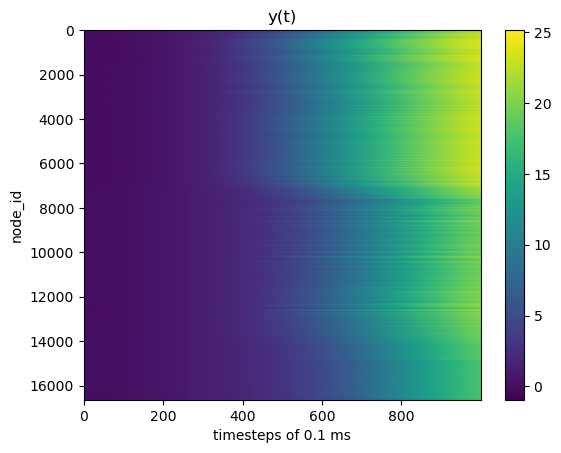

In [35]:
import matplotlib.pyplot as plt
plt.imshow(y.T,aspect='auto')
plt.title('y(t)')
plt.xlabel('timesteps of 0.1 ms')
plt.ylabel('node_id')
plt.colorbar()
plt.show()

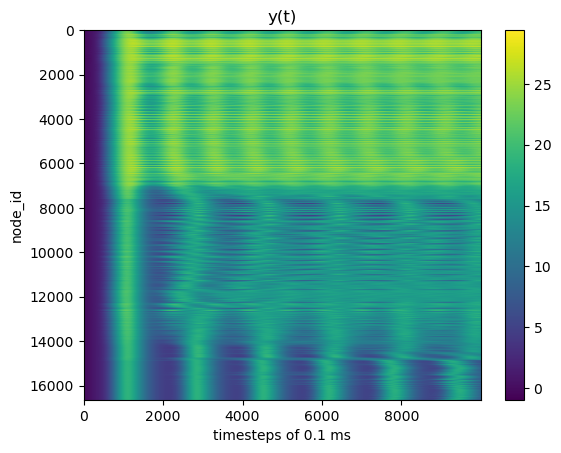

In [19]:
import matplotlib.pyplot as plt
plt.imshow(y.T,aspect='auto')
plt.title('y(t)')
plt.xlabel('timesteps of 0.1 ms')
plt.ylabel('node_id')
plt.colorbar()
plt.show()

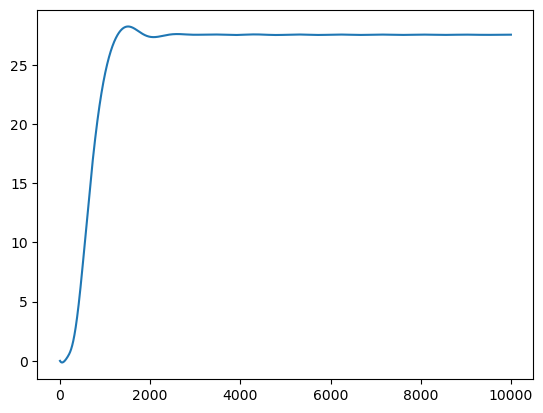

In [15]:
plt.plot(y[:,0])

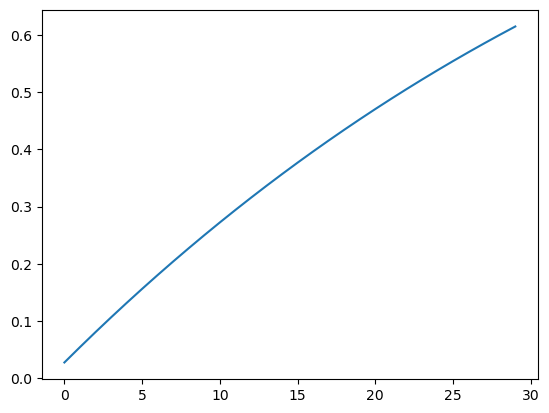

In [16]:
plt.plot(y4[:30,0])

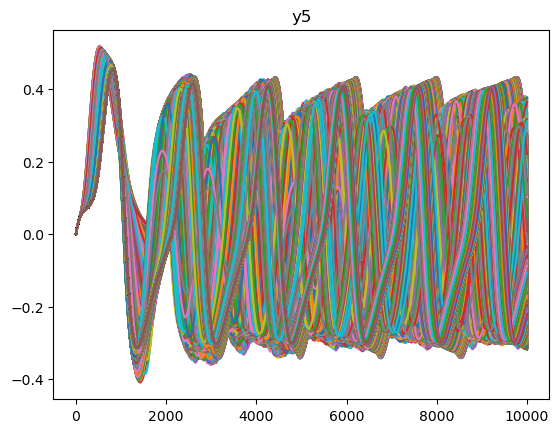

In [17]:
plt.plot(res[0][1][:,5,:,0])
plt.title('y5')
plt.show()

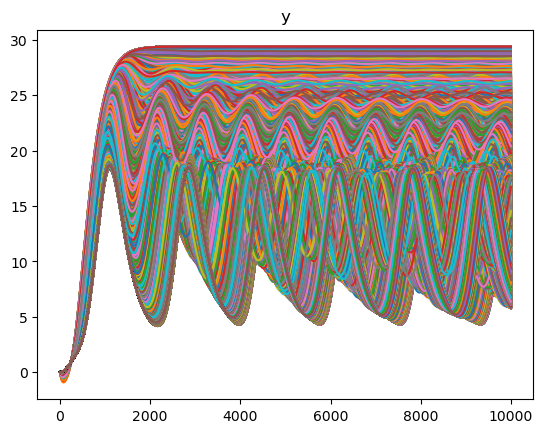

In [18]:
plt.plot(y)
plt.title('y')
plt.show()